# Прогноз цены жилья для агентства недвижимости

Итоговый проект 1 года SkillFactory, бриф 1

**Рубинштейн Андрей**, группа DSPR-192

## О проекте

Риелторы долго разбирают объявления и ищут выгодные лоты. Нужна оценка цены по характеристикам дома и сервис, который считает её быстро

Очистка лежит в `src/cleaning.py`: обучение и сервис чистят поля одинаково. Решение в этом ноутбуке, модель уходит в Flask

## Оглавление

1. [Данные и очистка](#sec-data)
2. [Статистика и признаки](#sec-stats)
   - [Промежуточный итог](#sec-mid)
3. [Модели](#sec-models)
   - [CatBoost, подбор параметров и SHAP](#sec-catboost)
4. [Сервис](#sec-service)
5. [Итоги](#sec-results)
   - [Цифры на тесте](#sec-results-metrics)
   - [Как до этого дошёл](#sec-results-story)
   - [Для агентства](#sec-results-biz)


In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import importlib
import src.cleaning
import src.features

importlib.reload(src.cleaning)
importlib.reload(src.features)
from src.cleaning import clean_listings, parse_zip

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

df_raw = pd.read_csv(ROOT / "data" / "data.csv", low_memory=False)
print(df_raw.shape)
df_raw.head(3)

(377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


<a id="sec-data"></a>

## 1. Данные и очистка

377 тысяч строк, 18 колонок. Почти всё пришло текстом: цена с долларом, площадь с подписью sqft, факты о доме и школы - словари в ячейке


private pool    98.89
mls-id          93.39
PrivatePool     89.31
fireplace       72.66
stories         39.96
baths           28.19
beds            24.20
MlsId           17.73
sqft            10.76
status          10.58
propertyType     9.21
target           0.66
city             0.01
street           0.00
zipcode          0.00
schools          0.00
state            0.00
homeFacts        0.00
dtype: float64
дубли: 50


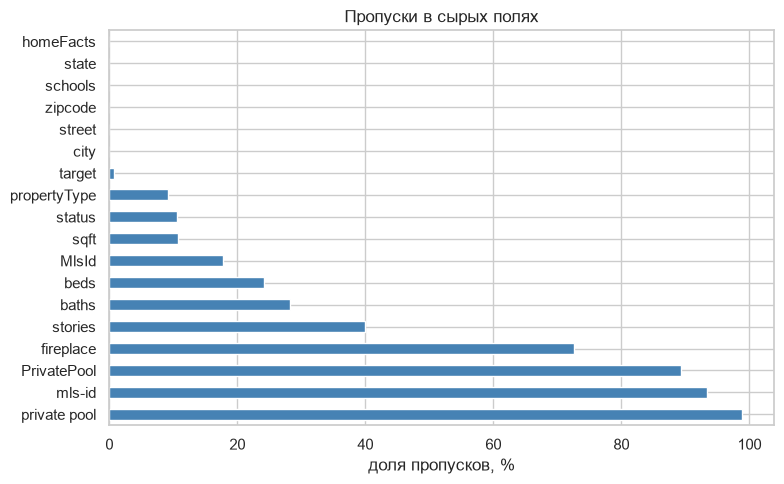

In [23]:
missing = df_raw.isna().mean().sort_values(ascending=False).mul(100)
print(missing.round(2))
print("дубли:", int(df_raw.duplicated().sum()))

fig, ax = plt.subplots(figsize=(8, 5))
missing.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("доля пропусков, %")
ax.set_title("Пропуски в сырых полях")
plt.tight_layout()
plt.show()

Колонка `private pool` почти пустая, зато есть вторая - `PrivatePool`. Склею их. MLS - номер объявления, в модель не пойдёт. Камин и этажи дырявые, из камина сделаю флаг есть или нет


In [24]:
print(df_raw["target"].head(8).tolist())
print(df_raw["sqft"].head(8).tolist())
print(df_raw["status"].value_counts(dropna=False).head(8))
print(df_raw["propertyType"].value_counts(dropna=False).head(8))

['$418,000', '$310,000', '$2,895,000', '$2,395,000', '$5,000', '$209,000', '181,500', '68,000']
['2900', '1,947 sqft', '3,000 sqft', '6,457 sqft', nan, '897 sqft', '1,507', nan]
status
for sale            156104
Active              105207
For sale             43465
NaN                  39918
foreclosure           6426
New construction      5475
Pending               4702
Pre-foreclosure       2119
Name: count, dtype: int64
propertyType
single-family home    92206
Single Family         62869
NaN                   34733
Single Family Home    31728
condo                 25968
lot/land              20552
Condo                 16561
townhouse             11464
Name: count, dtype: int64


Цена то с долларом, то без. Площадь то число, то с подписью sqft. Статус и тип написаны кучей вариантов. Участки без дома выкину - оцениваю жильё, не землю


In [25]:
print(df_raw.loc[0, "homeFacts"][:400])
print()
print(str(df_raw.loc[0, "schools"])[:400])

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}

[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', 'PK–2', '6–8', '9–12', 'PK–5', 'K–12']}, 'name': ['Southern Pines Elementary School', 'Southern Middle School', 'Pinecrest High School', 'Southern Pines Primary School', "Crain's Creek Middle School", 'Uni


В `homeFacts` сидит цена за квадратный фут. Если оставить - модель просто умножит площадь на эту цену. Это подглядывание в ответ, поле выкидываю. Из школ беру средний рейтинг и расстояние до ближайшей

Индекс оставляю: это район, не номер объявления. В лес тысячами столбцов не пойдёт, в CatBoost отдам как категорию

Правила разбора - в `src/cleaning.py`


In [26]:
df = clean_listings(df_raw)
if "zip_code" not in df.columns and "zipcode" in df.columns:
    df["zip_code"] = df["zipcode"].map(parse_zip)
print(df.shape)
print("колонки:", list(df.columns))
df.head(3)

(336075, 26)
колонки: ['status', 'propertyType', 'baths', 'city', 'sqft', 'beds', 'state', 'stories', 'price', 'baths_n', 'beds_n', 'stories_n', 'pool', 'fireplace_flg', 'year_built', 'lotsize', 'remodeled', 'has_heating', 'has_cooling', 'has_parking', 'school_rating', 'school_dist', 'n_schools', 'status_grp', 'type_grp', 'zip_code']


,status,propertyType,baths,city,sqft,beds,state,stories,price,baths_n,beds_n,stories_n,pool,fireplace_flg,year_built,lotsize,remodeled,has_heating,has_cooling,has_parking,school_rating,school_dist,n_schools,status_grp,type_grp,zip_code
0,Active,Single Family Home,3.5,Southern Pines,2900.0,4,NC,NaN,418000.0,3.5,4.0,NaN,0,1,2019.0,NaN,0.0,1.0,0.0,0.0,5.200000,2.70,8.0,for_sale,single_family,28387
1,for sale,single-family home,3 Baths,Spokane Valley,1947.0,3 Beds,WA,2.0,310000.0,3.0,3.0,2.0,0,0,2019.0,5828.0,0.0,0.0,0.0,0.0,6.000000,1.01,3.0,for_sale,single_family,99216
2,for sale,single-family home,2 Baths,Los Angeles,3000.0,3 Beds,CA,1.0,2895000.0,2.0,3.0,1.0,1,1,1961.0,8626.0,1.0,1.0,1.0,1.0,6.666667,1.19,3.0,for_sale,single_family,90049


После очистки около 336 тысяч лотов: убрал дубли, землю, цену вне 10 тысяч-5 млн и строки без цены


In [27]:
print(df[["price", "sqft", "baths_n", "beds_n", "year_built",
         "school_rating", "lotsize"]].describe().T.round(1))
print()
print("пропуски после очистки, %")
print(df.isna().mean().mul(100).round(1).sort_values(ascending=False).head(12))

                  count      mean       std      min       25%       50%  \
price          336075.0  532947.6  623807.3  10000.0  209997.5  337000.0   
sqft           311356.0    2128.4    1291.7    120.0    1298.0    1828.0   
baths_n        244662.0       2.7       1.2      0.8       2.0       2.5   
beds_n         256172.0       3.3       1.2      0.0       3.0       3.0   
year_built     301673.0    1979.9      33.2   1703.0    1958.0    1986.0   
school_rating  332251.0       5.2       2.0      1.0       3.7       5.3   
lotsize        243287.0   28411.3  156349.8    200.0    5035.0    7809.0   

                    75%        max  
price          590000.0  5000000.0  
sqft             2584.0    20000.0  
baths_n             3.0       20.0  
beds_n              4.0       20.0  
year_built       2007.0     2025.0  
school_rating       6.7       10.0  
lotsize         12632.4  4991976.0  

пропуски после очистки, %
stories_n        35.5
stories          34.7
lotsize          27.6
ba

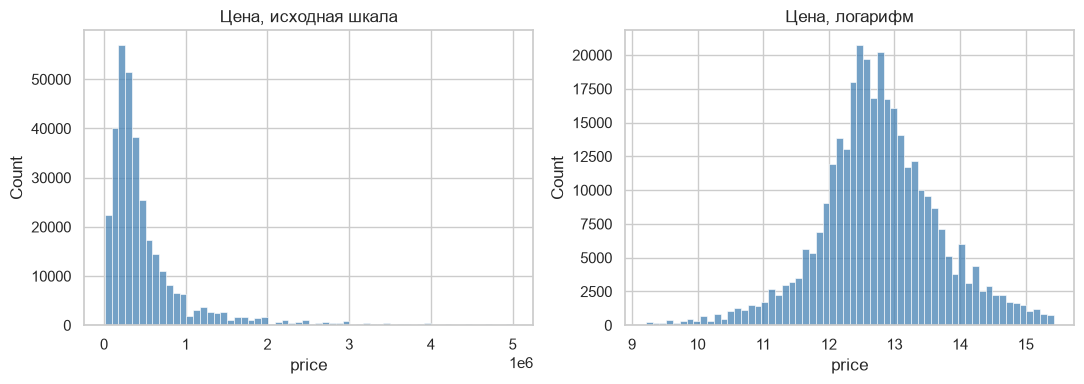

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["price"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Цена, исходная шкала")
sns.histplot(np.log1p(df["price"]), bins=60, ax=axes[1], color="steelblue")
axes[1].set_title("Цена, логарифм")
plt.tight_layout()
plt.show()

Цена скошена вправо. На логарифме ближе к колоколу - ниже проверю тестом и буду учить модель на логарифме цены


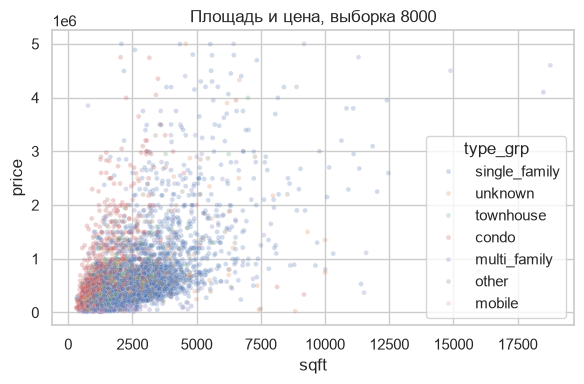

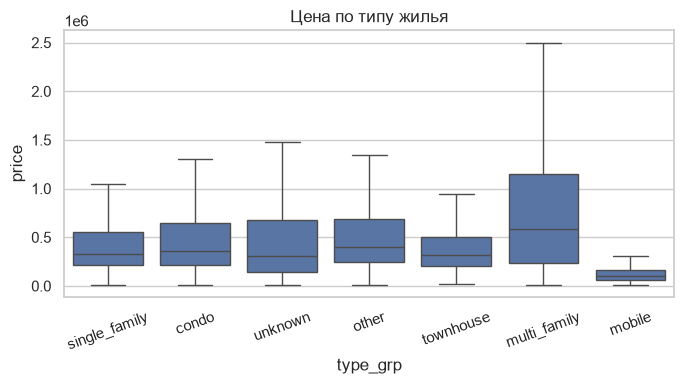

In [29]:
sample = df.dropna(subset=["sqft"]).sample(8000, random_state=42)
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=sample, x="sqft", y="price", hue="type_grp",
    alpha=0.25, s=12, ax=ax,
)
ax.set_title("Площадь и цена, выборка 8000")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
order = df["type_grp"].value_counts().index
sns.boxplot(data=df, x="type_grp", y="price", order=order, ax=ax,
            showfliers=False)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Цена по типу жилья")
plt.tight_layout()
plt.show()

Площадь с ценой растут вместе, разброс большой - одной площадью не обойтись. Кондо дешевле отдельно стоящих домов. Дальше это не на глаз, а тестами


<a id="sec-stats"></a>

## 2. Статистика и признаки

Каждый тест ниже решает, что идёт в модель


Гипотеза: логарифм цены ближе к нормальному. Шапиро на всей таблице при таком размере бесполезен, поэтому беру 5000 строк


In [30]:
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=5000, replace=False)
price = df.loc[df.index[idx], "price"]
log_price = np.log1p(price)

stat_p, p_p = stats.shapiro(price)
stat_l, p_l = stats.shapiro(log_price)
print("Шапиро цена: stat=%.3f p=%.2e" % (stat_p, p_p))
print("Шапиро логарифм: stat=%.3f p=%.2e" % (stat_l, p_l))
print("skew цена", round(df["price"].skew(), 2),
      "skew log", round(np.log1p(df["price"]).skew(), 2))

Шапиро цена: stat=0.627 p=6.16e-74
Шапиро логарифм: stat=0.983 p=3.99e-24
skew цена 3.36 skew log -0.08


Формально оба распределения не нормальные - при пяти тысячах Шапиро почти всегда ругается. Асимметрия падает сильно, для регрессии беру логарифм цены


In [31]:
pair = df.dropna(subset=["sqft", "price"])
rho, p_rho = stats.spearmanr(pair["sqft"], pair["price"])
print("Спирмен sqft-price: rho=%.3f p=%.2e n=%d" % (rho, p_rho, len(pair)))

Спирмен sqft-price: rho=0.540 p=0.00e+00 n=311356


Связь значимая, площадь обязательна. Пропуски заполню медианой внутри типа жилья и только по обучающей выборке, иначе подгляжу в тест


n с бассейном 42245 без 293830
медиана с 449900 без 324900
Манн-Уитни U=7742682424 p=0.00e+00


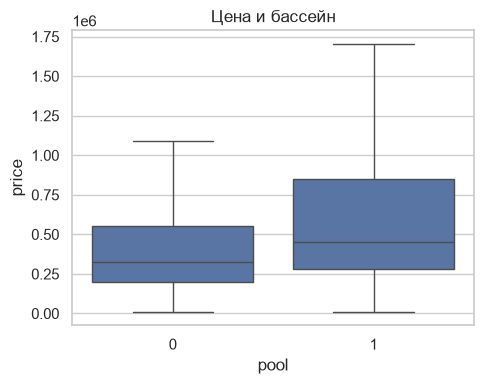

In [32]:
with_pool = df.loc[df["pool"] == 1, "price"]
no_pool = df.loc[df["pool"] == 0, "price"]
u, p_u = stats.mannwhitneyu(with_pool, no_pool, alternative="two-sided")
print("n с бассейном", len(with_pool), "без", len(no_pool))
print("медиана с", int(with_pool.median()), "без", int(no_pool.median()))
print("Манн-Уитни U=%.0f p=%.2e" % (u, p_u))

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x="pool", y="price", showfliers=False, ax=ax)
ax.set_title("Цена и бассейн")
plt.tight_layout()
plt.show()

Разница есть, бассейн оставляю флагом есть или нет


In [33]:
if "zip_code" not in df.columns:
    from src.cleaning import parse_zip
    if "zipcode" in df.columns:
        df["zip_code"] = df["zipcode"].map(parse_zip)
    else:
        df = clean_listings(df_raw)

groups = [
    g["price"].to_numpy()
    for _, g in df.groupby("type_grp")
    if len(g) > 30
]
h, p_h = stats.kruskal(*groups)
print("Краскел-Уоллис по типу H=%.1f p=%.2e, групп=%d" % (h, p_h, len(groups)))
print(df.groupby("type_grp")["price"].median().sort_values())

top_states = df["state"].value_counts().head(8).index
sub = df[df["state"].isin(top_states)]
state_groups = [g["price"].to_numpy() for _, g in sub.groupby("state")]
h_s, p_s = stats.kruskal(*state_groups)
print("Краскел по топ-8 штатам H=%.1f p=%.2e" % (h_s, p_s))

status_groups = [
    g["price"].to_numpy()
    for _, g in df.groupby("status_grp")
    if len(g) > 30
]
h_st, p_st = stats.kruskal(*status_groups)
print("Краскел по статусу H=%.1f p=%.2e" % (h_st, p_st))
print(df.groupby("status_grp")["price"].median().sort_values())

top_zips = df["zip_code"].value_counts().head(12).index
sub_z = df[df["zip_code"].isin(top_zips)]
zip_groups = [g["price"].to_numpy() for _, g in sub_z.groupby("zip_code")]
h_z, p_z = stats.kruskal(*zip_groups)
print("Краскел по топ-12 индексам H=%.1f p=%.2e" % (h_z, p_z))
print("уникальных индексов", df["zip_code"].nunique())
print(sub_z.groupby("zip_code")["price"].median().sort_values().head(6))


Краскел-Уоллис по типу H=9432.4 p=0.00e+00, групп=7
type_grp
mobile            99900.0
unknown          310000.0
townhouse        318000.0
single_family    329000.0
condo            361000.0
other            399000.0
multi_family     585000.0
Name: price, dtype: float64
Краскел по топ-8 штатам H=44613.9 p=0.00e+00
Краскел по статусу H=4890.2 p=0.00e+00
status_grp
foreclosure    204700.0
sold           207000.0
other          247500.0
pending        269400.0
auction        303931.0
unknown        324093.0
for_sale       349000.0
Name: price, dtype: float64
Краскел по топ-12 индексам H=5429.8 p=0.00e+00
уникальных индексов 4179
zip_code
78245    246000.0
78254    270099.0
34746    273490.0
78253    289667.5
32137    349900.0
34747    389500.0
Name: price, dtype: float64


Тип, статус и штат держат цену, их имеет смысл кодировать отдельными столбцами. Редкие штаты сверну в группу other, список частых возьму только с обучения

По топ-12 индексам медианы тоже разные - индекс это район, не мусорный id. В линейку и лес тысячами столбцов не запихну, в CatBoost отдам как категорию. Редкие индексы (меньше 30 на обучении) схлопну в other


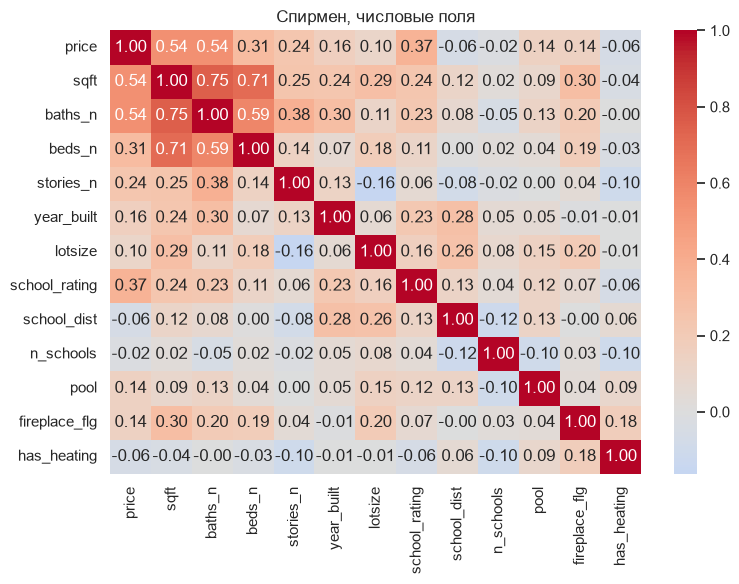

interval columns not set, guessing: ['price', 'sqft', 'baths_n', 'year_built', 'school_rating', 'pool']


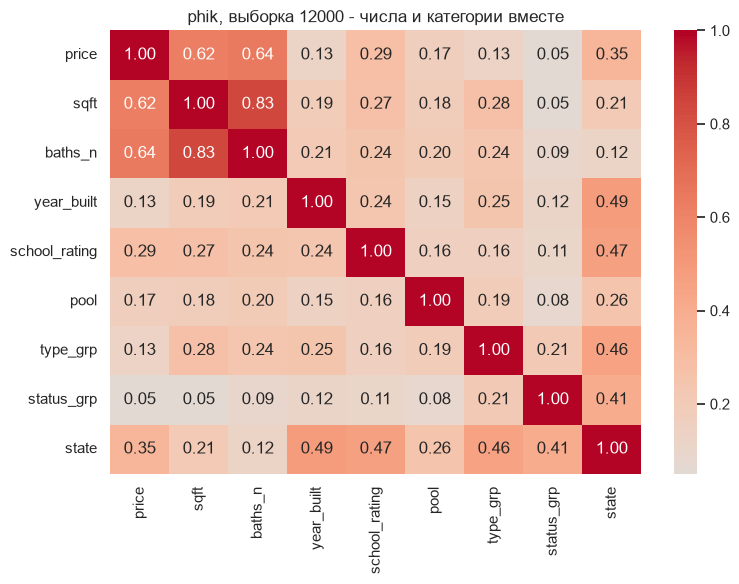

price            1.000
baths_n          0.643
sqft             0.619
state            0.350
school_rating    0.290
pool             0.170
type_grp         0.132
year_built       0.125
status_grp       0.054
Name: price, dtype: float64


In [34]:
num_cols = [
    "price", "sqft", "baths_n", "beds_n", "stories_n",
    "year_built", "lotsize", "school_rating", "school_dist", "n_schools",
    "pool", "fireplace_flg", "has_heating",
]
corr = df[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Спирмен, числовые поля")
plt.tight_layout()
plt.show()

import phik

phi_cols = [
    "price", "sqft", "baths_n", "year_built", "school_rating",
    "pool", "type_grp", "status_grp", "state",
]
phi_sample = df[phi_cols].sample(12000, random_state=42)
phi = phi_sample.phik_matrix()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(phi, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("phik, выборка 12000 - числа и категории вместе")
plt.tight_layout()
plt.show()
print(phi["price"].sort_values(ascending=False).round(3))


Спальни и ванные связаны с площадью, но не до единицы - все три оставляю. Число школ рядом с рейтингом почти бесполезно, в модель не беру

Городов сотни, в лес их отдельными столбцами не запихнуть. Индекс ещё пестрее. В CatBoost и город, и индекс верну: он умеет категории как есть

Отопление, кондиционер и парковка в тексте - каша формулировок. В модель идут только флаги есть или нет

Матрица phik смотрит и числа, и категории сразу. Если штат и тип с ценой связаны сильно - кодировать их отдельными столбцами не выдумка

В лес и линейку: площадь, ванные, спальни, этажи, год, участок, рейтинг школ, расстояние, бассейн, камин, ремонт, отопление, кондиционер, парковка, тип, статус, штат. В CatBoost плюс город и индекс. Цель - цена на логарифме


<a id="sec-mid"></a>

## Промежуточный итог

Сырой файл нельзя кормить модели: цена и площадь - текст, два бассейна, цена за фут - это подсказка ответа, земля вперемешку с домами. Лог цены, площадь, бассейн, тип, штат и индекс подтвердил тестами, не только графиками. Индекс сначала хотел выкинуть как id - Краскел сказал, что это район

Дальше сравниваю медиану, линейку, лес, стекинг и CatBoost. Город и индекс отдам только CatBoost


<a id="sec-models"></a>

## 3. Модели

Сначала наивное: медиана цены на обучении и медиана по штату. Потом линейная регрессия, Ridge, случайный лес и градиентный бустинг из sklearn. Лес и бустинг sklearn склею стекингом. Потом CatBoost: категории без кучи бинарных столбцов, плюс город и индекс

Целевую учу как логарифм цены, на тесте возвращаю обратно в доллары и обрезаю к 10 тысячам-5 млн, как при очистке

Делю 80/20, `random_state=42`. Редкие штаты (меньше 400 объявлений), города (меньше 200) и индексы (меньше 30) схлопываю в other **только по обучающей выборке**

Пропуски площади заполняю медианой типа жилья с обучения

Гиперпараметры леса и обычного бустинга подбираю случайным поиском на 20 тысячах строк. У CatBoost - Optuna на куске обучения, остановку по ошибке на валидации из обучения. На обучении ещё смотрю 3 фолда, тест не трогаю, пока не сравню всех


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

from src.features import CAT_COLS, CB_CAT_COLS, NUM_COLS, prepare_frame

if "zip_code" not in df.columns:
    if "zipcode" in df.columns:
        df["zip_code"] = df["zipcode"].map(parse_zip)
    else:
        df = clean_listings(df_raw)

X_all = df[NUM_COLS + CB_CAT_COLS].copy()
y = df["price"].copy()
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

state_counts = X_train_all["state"].value_counts()
state_keep = set(state_counts[state_counts >= 400].index)
city_raw = X_train_all["city"].fillna("unknown").astype(str).str.strip()
city_keep = set(city_raw.value_counts()[city_raw.value_counts() >= 200].index)
zip_raw = X_train_all["zip_code"].fillna("unknown").astype(str)
zip_keep = set(zip_raw.value_counts()[zip_raw.value_counts() >= 30].index)
sqft_medians = X_train_all.groupby("type_grp")["sqft"].median().to_dict()
sqft_fallback = float(X_train_all["sqft"].median())

X_train_all = prepare_frame(
    X_train_all, state_keep, city_keep, zip_keep, sqft_medians, sqft_fallback
)
X_test_all = prepare_frame(
    X_test_all, state_keep, city_keep, zip_keep, sqft_medians, sqft_fallback
)

X_train = X_train_all[NUM_COLS + CAT_COLS]
X_test = X_test_all[NUM_COLS + CAT_COLS]
X_train_cb = X_train_all[NUM_COLS + CB_CAT_COLS]
X_test_cb = X_test_all[NUM_COLS + CB_CAT_COLS]
y_train_log = np.log1p(y_train)
print("train", X_train.shape, "test", X_test.shape)
print("городов в keep:", len(city_keep))
print("индексов в keep:", len(zip_keep))
print("доля state=other: %.3f" % (X_train_all["state"] == "other").mean())
print("доля city=other: %.3f" % (X_train_all["city"] == "other").mean())
print("доля zip=other: %.3f" % (X_train_all["zip_code"] == "other").mean())


train (268860, 17) test (67215, 17)
городов в keep: 190
индексов в keep: 1951
доля state=other: 0.004
доля city=other: 0.165
доля zip=other: 0.078


Медианы, частые штаты, города и индексы считаются на обучении. Тест эти правила только применяет


In [36]:
pre_lin = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUM_COLS,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CAT_COLS,
        ),
    ]
)

pre_tree = ColumnTransformer(
    [
        ("num", SimpleImputer(strategy="median"), NUM_COLS),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    (
                        "ohe",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            CAT_COLS,
        ),
    ]
)


def report(name, pred):
    pred = np.clip(pred, 10_000, 5_000_000)
    mae = mean_absolute_error(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("%-18s MAE=%s  MAPE=%.3f  R2=%.3f" % (
        name, format(mae, ",.0f"), mape, r2
    ))
    return mae


pred_med = np.full(len(y_test), y_train.median())
report("median", pred_med)
state_med = y_train.groupby(X_train["state"]).median()
pred_state = X_test["state"].map(state_med).fillna(y_train.median())
report("median_by_state", pred_state)

median             MAE=335,263  MAPE=0.969  R2=-0.103
median_by_state    MAE=307,860  MAPE=0.859  R2=0.035


307859.56518634234

Медиана по штату уже лучше глобальной. Если бустинг это не отобьёт - модель не нужна


In [37]:
gbr_for_search = Pipeline(
    [
        ("pre", pre_tree),
        (
            "model",
            GradientBoostingRegressor(
                min_samples_split=30,
                random_state=42,
            ),
        ),
    ]
)

tune_n = 20000
tune_idx = np.random.default_rng(42).choice(
    len(X_train), size=tune_n, replace=False
)
search = RandomizedSearchCV(
    gbr_for_search,
    param_distributions={
        "model__max_depth": [3, 4, 5],
        "model__n_estimators": [60, 100],
        "model__learning_rate": [0.05, 0.1],
    },
    n_iter=4,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
)
search.fit(X_train.iloc[tune_idx], y_train_log.iloc[tune_idx])
print("лучшие параметры бустинга:", search.best_params_)

gbr_params = {"min_samples_split": 30, "random_state": 42}
for key, value in search.best_params_.items():
    gbr_params[key.replace("model__", "")] = value

rf_search = RandomizedSearchCV(
    Pipeline(
        [
            ("pre", pre_tree),
            ("model", RandomForestRegressor(n_jobs=-1, random_state=42)),
        ]
    ),
    param_distributions={
        "model__max_depth": [10, 12, 14],
        "model__n_estimators": [40, 60],
        "model__min_samples_leaf": [4, 8],
    },
    n_iter=4,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
)
rf_search.fit(X_train.iloc[tune_idx], y_train_log.iloc[tune_idx])
print("лучшие параметры леса:", rf_search.best_params_)
rf_params = {"n_jobs": -1, "random_state": 42}
for key, value in rf_search.best_params_.items():
    rf_params[key.replace("model__", "")] = value

models = {
    "linreg": Pipeline([
        ("pre", pre_lin),
        ("model", LinearRegression()),
    ]),
    "ridge": Pipeline([
        ("pre", pre_lin),
        ("model", Ridge(alpha=1.0)),
    ]),
    "rf": Pipeline([
        ("pre", pre_tree),
        (
            "model",
            RandomForestRegressor(**rf_params),
        ),
    ]),
    "gbr": Pipeline([
        ("pre", pre_tree),
        ("model", GradientBoostingRegressor(**gbr_params)),
    ]),
}

best_name, best_mae, best_pipe = None, 10 ** 18, None
for name, pipe in models.items():
    pipe.fit(X_train, y_train_log)
    pred = np.expm1(pipe.predict(X_test))
    mae = report(name, pred)
    if mae < best_mae:
        best_name, best_mae, best_pipe = name, mae, pipe

stack = StackingRegressor(
    estimators=[
        ("ridge", models["ridge"]),
        ("rf", models["rf"]),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=1,
)
stack.fit(X_train, y_train_log)
mae_stack = report("stack_ridge_rf", np.expm1(stack.predict(X_test)))
if mae_stack < best_mae:
    best_name, best_mae, best_pipe = "stack_ridge_rf", mae_stack, stack

print("лучшая:", best_name)


лучшие параметры бустинга: {'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}
лучшие параметры леса: {'model__n_estimators': 60, 'model__min_samples_leaf': 4, 'model__max_depth': 14}
linreg             MAE=234,312  MAPE=0.572  R2=0.386
ridge              MAE=234,310  MAPE=0.572  R2=0.386
rf                 MAE=182,768  MAPE=0.418  R2=0.633
gbr                MAE=199,242  MAPE=0.456  R2=0.547
stack_ridge_rf     MAE=182,477  MAPE=0.416  R2=0.640
лучшая: stack_ridge_rf


На моём прогоне (`random_state=42`):

- медиана: MAE 335 тыс., MAPE 0.97, R2 -0.10
- медиана по штату: 308 тыс., MAPE 0.86, R2 0.04
- линейка и Ridge: 234 тыс., MAPE 0.57, R2 0.39
- случайный лес после сетки: 183 тыс., MAPE 0.42, R2 0.63
- градиентный бустинг sklearn: 199 тыс., MAPE 0.46, R2 0.55
- стекинг Ridge + лес: 182 тыс., MAPE 0.42, R2 0.64 - почти как лес, города и индекса в sklearn нет

Лес точнее обычного бустинга. Дальше CatBoost с городом и индексом


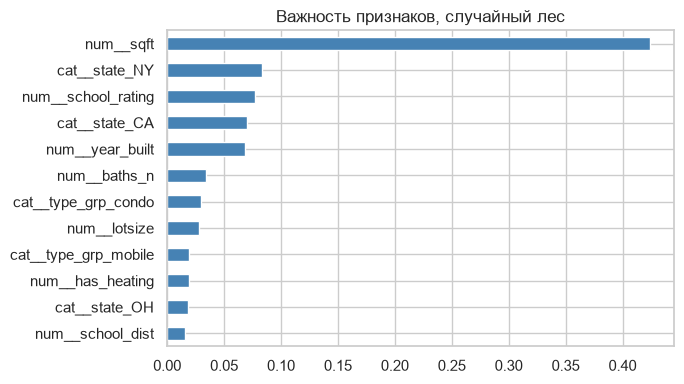

num__sqft               0.424
cat__state_NY           0.083
num__school_rating      0.078
cat__state_CA           0.070
num__year_built         0.068
num__baths_n            0.034
cat__type_grp_condo     0.030
num__lotsize            0.028
cat__type_grp_mobile    0.019
num__has_heating        0.019
cat__state_OH           0.018
num__school_dist        0.016
dtype: float64


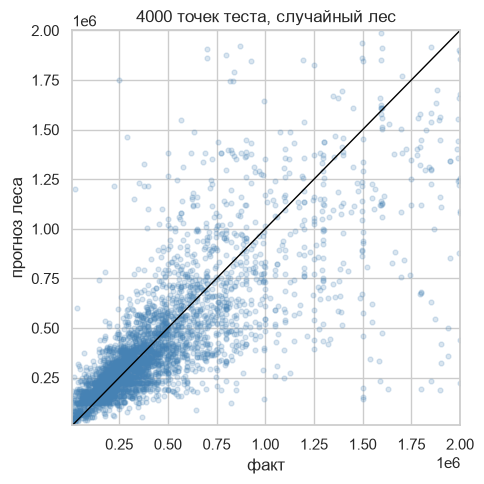

In [38]:
rf_pipe = models["rf"]
names = rf_pipe.named_steps["pre"].get_feature_names_out()
imp = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=names
).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Важность признаков, случайный лес")
plt.tight_layout()
plt.show()
print(imp.round(3))

pred_rf = np.clip(np.expm1(rf_pipe.predict(X_test)), 10_000, 5_000_000)
sample_idx = np.random.default_rng(42).choice(len(X_test), size=4000, replace=False)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    y_test.iloc[sample_idx], pred_rf[sample_idx],
    alpha=0.2, s=12, color="steelblue",
)
lims = [10_000, 2_000_000]
ax.plot(lims, lims, color="black", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("факт")
ax.set_ylabel("прогноз леса")
ax.set_title("4000 точек теста, случайный лес")
plt.tight_layout()
plt.show()


У леса наверху площадь и штаты Нью-Йорк и Калифорния. Бассейн слабее, но тест Манн-Уитни разницу по цене показывал - оставляю

На графике лес мажет дорогие дома. Смотрю, вытянет ли CatBoost с городом и индексом


<a id="sec-catboost"></a>

## 3.1 CatBoost, подбор параметров и SHAP

Сотни городов и тысячи индексов в лес отдельными столбцами не запихнуть. CatBoost берёт категории как есть. Параметры кручу Optuna на куске обучения, останавливаюсь, когда ошибка на валидации из обучения перестаёт падать. На обучении считаю MAE по 3 фолдам. Тест - один раз, в конце

phik уже показал связь штата и типа с ценой. SHAP покажет, дали ли город и индекс вклад в прогноз


In [39]:
from catboost import CatBoostRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr_cb, X_val_cb, y_tr_cb, y_val_cb = train_test_split(
    X_train_cb, y_train, test_size=0.12, random_state=42
)
y_tr_log = np.log1p(y_tr_cb)
y_val_log = np.log1p(y_val_cb)

tune_n = min(30000, len(X_tr_cb))
tune_idx = np.random.default_rng(42).choice(len(X_tr_cb), size=tune_n, replace=False)
X_tune = X_tr_cb.iloc[tune_idx]
y_tune = y_tr_log.iloc[tune_idx]
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_tune, y_tune, test_size=0.2, random_state=42
)


def objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 6, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.04, 0.12, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 6.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 80),
        "iterations": 220,
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 0,
        "early_stopping_rounds": 30,
        "cat_features": CB_CAT_COLS,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_tune_tr, y_tune_tr, eval_set=(X_tune_val, y_tune_val))
    pred = np.clip(np.expm1(model.predict(X_val_cb)), 10_000, 5_000_000)
    return mean_absolute_error(y_val_cb, pred)


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=6)
print("лучшие параметры CatBoost на куске:", study.best_params)
print("MAE на val при подборе:", round(study.best_value))

cb_params = {
    "depth": 8,
    "learning_rate": 0.07,
    "l2_leaf_reg": 1.5,
    "min_data_in_leaf": 40,
    "iterations": 1800,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0,
    "early_stopping_rounds": 80,
    "cat_features": CB_CAT_COLS,
}
print("на полном объёме беру depth=8, шаг 0.07, 1800 деревьев")

kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_n = min(60000, len(X_train_cb))
cv_idx = np.random.default_rng(0).choice(len(X_train_cb), size=cv_n, replace=False)
X_cv = X_train_cb.iloc[cv_idx]
y_cv = y_train.iloc[cv_idx]
cv_mae = []
for fold, (tr, va) in enumerate(kf.split(X_cv), 1):
    cv_model = CatBoostRegressor(
        depth=cb_params["depth"],
        learning_rate=cb_params["learning_rate"],
        l2_leaf_reg=cb_params["l2_leaf_reg"],
        min_data_in_leaf=cb_params["min_data_in_leaf"],
        iterations=400,
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
        cat_features=CB_CAT_COLS,
    )
    cv_model.fit(X_cv.iloc[tr], np.log1p(y_cv.iloc[tr]))
    pred_fold = np.clip(
        np.expm1(cv_model.predict(X_cv.iloc[va])), 10_000, 5_000_000
    )
    mae_fold = mean_absolute_error(y_cv.iloc[va], pred_fold)
    cv_mae.append(mae_fold)
    print("фолд %d MAE=%s" % (fold, format(mae_fold, ",.0f")))
print(
    "CV MAE mean=%s std=%s"
    % (format(np.mean(cv_mae), ",.0f"), format(np.std(cv_mae), ",.0f"))
)

cb_model = CatBoostRegressor(**cb_params)
cb_model.fit(X_tr_cb, y_tr_log, eval_set=(X_val_cb, y_val_log))
pred_cb = np.expm1(cb_model.predict(X_test_cb))
cb_mae = report("catboost", pred_cb)
if cb_mae < best_mae:
    best_name, best_mae = "catboost", cb_mae
print("лучшая сейчас:", best_name)
print("деревьев после остановки:", cb_model.get_best_iteration())


лучшие параметры CatBoost на куске: {'depth': 9, 'learning_rate': 0.08707559847702265, 'l2_leaf_reg': 1.1029224714790122, 'min_data_in_leaf': 79}
MAE на val при подборе: 153380
на полном объёме беру depth=8, шаг 0.07, 1800 деревьев
фолд 1 MAE=151,610
фолд 2 MAE=152,063
фолд 3 MAE=149,524
CV MAE mean=151,066 std=1,106
catboost           MAE=126,841  MAPE=0.244  R2=0.768
лучшая сейчас: catboost
деревьев после остановки: 1798


CatBoost на тесте: MAE 127 тыс., MAPE 0.24, R2 0.77. Лес 183 тыс., стекинг 182 тыс. - индекс и город как категории делают разницу. 3 фолда на куске обучения: MAE около 151 тыс. при 400 деревьях, разброс около 1 тыс. На полном обучении ошибка ниже

В сервис кладу CatBoost


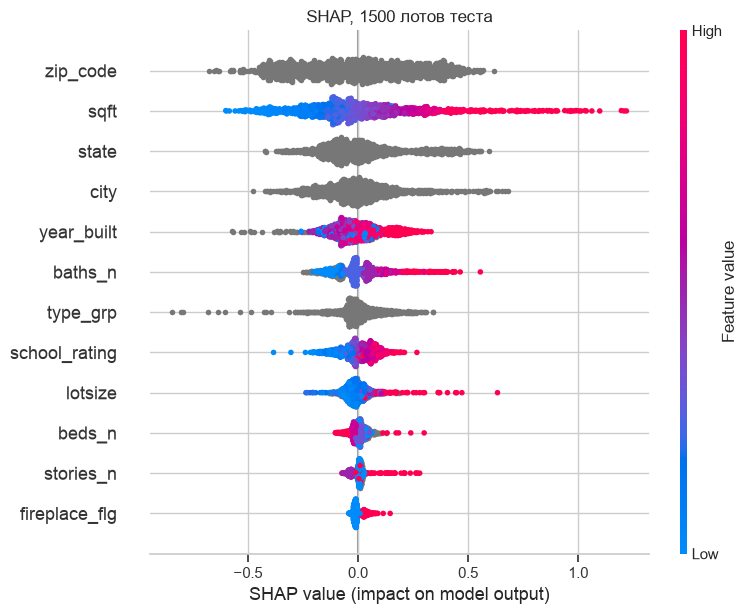

zip_code         0.218
sqft             0.204
state            0.134
city             0.120
year_built       0.090
baths_n          0.084
type_grp         0.064
school_rating    0.058
lotsize          0.041
beds_n           0.024
stories_n        0.019
fireplace_flg    0.019
dtype: float64


In [40]:
import shap

shap_n = min(1500, len(X_test_cb))
shap_idx = np.random.default_rng(42).choice(len(X_test_cb), size=shap_n, replace=False)
shap_x = X_test_cb.iloc[shap_idx]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(shap_x)

fig = plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, shap_x, show=False, max_display=12)
plt.title("SHAP, 1500 лотов теста")
plt.tight_layout()
plt.show()

mean_abs = pd.Series(
    np.abs(shap_values).mean(axis=0), index=shap_x.columns
).sort_values(ascending=False)
print(mean_abs.round(3).head(12))


По среднему модулю SHAP на тесте: индекс, площадь, штат, город. Их стоило отдать CatBoost, а не лесу кучей столбцов

Бассейн и парковка слабые. Риелтор их всё равно указывает в форме, оставляю. Сохраняю CatBoost: на тесте он лучше стекинга и леса


In [41]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
bundle = {
    "kind": "catboost" if best_name == "catboost" else "sklearn",
    "model": cb_model if best_name == "catboost" else None,
    "pipeline": None if best_name == "catboost" else best_pipe,
    "num_cols": NUM_COLS,
    "cat_cols": CAT_COLS,
    "cb_cat_cols": CB_CAT_COLS,
    "state_keep": sorted(state_keep),
    "city_keep": sorted(city_keep),
    "zip_keep": sorted(zip_keep),
    "sqft_medians": sqft_medians,
    "sqft_fallback": sqft_fallback,
    "model_name": best_name,
}
joblib.dump(bundle, models_dir / "price_model.joblib", compress=3)
print("сохранил", best_name, models_dir / "price_model.joblib")


сохранил catboost /Users/andrey/Desktop/sf/Блок 8. Итоговый проект 1 года/realty/models/price_model.joblib


<a id="sec-service"></a>

## 4. Сервис

Модель лежит в `models/price_model.joblib`. Сервис читает те же поля и те же списки штатов, городов и индексов

```bash
python web/app.py
python web/client.py
```

Docker:

```bash
docker build -t realty-price .
docker run -p 5001:5001 realty-price
```

Порт 5001: на маке 5000 часто занят трансляцией экрана

Запрос `POST /predict` принимает признаки дома. Если передать цену в объявлении (`listed_price`), сервис вернёт разницу и флаг: лот дешевле модели, риелтору имеет смысл смотреть раньше


In [42]:
demo = X_test_cb.iloc[[0]].copy()
demo_price = float(y_test.iloc[0])
if best_name == "catboost":
    hat = float(np.clip(np.expm1(cb_model.predict(demo)[0]), 10_000, 5_000_000))
else:
    hat = float(np.clip(
        np.expm1(best_pipe.predict(demo[NUM_COLS + CAT_COLS])[0]),
        10_000, 5_000_000,
    ))
print("факт", round(demo_price), "прогноз", round(hat),
      "delta listed-pred", round(demo_price - hat))
print(demo.to_dict(orient="records")[0])


факт 1218600 прогноз 793368 delta listed-pred 425232
{'sqft': 1626.0, 'baths_n': 3.0, 'beds_n': 3.0, 'stories_n': 3.0, 'year_built': nan, 'lotsize': nan, 'school_rating': 5.0, 'school_dist': 0.48, 'pool': 0, 'fireplace_flg': 0, 'remodeled': 0.0, 'has_heating': 0.0, 'has_cooling': 0.0, 'has_parking': 0.0, 'type_grp': 'townhouse', 'status_grp': 'for_sale', 'state': 'CA', 'city': 'other', 'zip_code': 'other'}


<a id="sec-results"></a>

## Итоги

Ну что, пора подвести итог всей работы. Ниже цифры на тесте, как я добирался до этой модели и что из неё получается для риелтора

<a id="sec-results-metrics"></a>

### Цифры на тесте

Деление 80/20, `random_state=42`, цель - цена в долларах после `expm1`

| модель | MAE | MAPE | R2 |
|---|---|---|---|
| медиана | 335 тыс. | 0.97 | -0.10 |
| медиана по штату | 308 тыс. | 0.86 | 0.04 |
| линейка / Ridge | 234 тыс. | 0.57 | 0.39 |
| бустинг sklearn | 199 тыс. | 0.46 | 0.55 |
| случайный лес (сетка на 20 тыс.) | 183 тыс. | 0.42 | 0.63 |
| стекинг Ridge + лес | 182 тыс. | 0.42 | 0.64 |
| **CatBoost** | **127 тыс.** | **0.24** | **0.77** |

Медиана ошибается на треть миллиона - без модели риелтор слепой. Лес уже сильно лучше линейки. Стекинг Ridge+лес почти не двигает лес: в sklearn нет города и индекса, мета-модель не из чего выигрывать. CatBoost с категориями режет ошибку ещё примерно на 55 тысяч относительно леса

3 фолда на куске обучения (400 деревьев): MAE около 151 тыс., разброс около 1 тыс. На полном обучении 1800 деревьев с ранней остановкой тест дал 127 тыс. Разброс маленький, в тест не подглядывал

<a id="sec-results-story"></a>

### Как до этого дошёл

Сырой файл нельзя кормить модели. Цена то с долларом, то без. Два столбца бассейна. Факты о доме и школы - словари в ячейке. Цену за фут выкинул сразу: это та же цена, поделённая на площадь

После очистки около 336 тысяч жилых лотов, цена от 10 тысяч до 5 млн. Землю без дома убрал

Лог цены ближе к колоколу, площадь связана с ценой по Спирмену, бассейн отличается по Манну-Уитни, тип/штат/статус/индекс - по Краскелу. Эти тесты не для галочки: от них зависит, что идёт в модель. Пропуски площади закрываю медианой типа жилья и только с обучения

Индекс сначала хотел выкинуть как id объявления. Краскел по топ-12 индексам показал разные медианы - это район, не мусор. В лес тысячами столбцов не запихнуть, в CatBoost отдал как категорию вместе с городом. SHAP это подтвердил: индекс первый по среднему модулю вклада, потом площадь, штат и город

Сетку у леса и sklearn-бустинга крутил случайным поиском на 20 тысячах. Optuna у CatBoost на куске train выбрала глубину 9. На полном объёме оставил глубину 8, шаг 0.07 и 1800 деревьев - так стабильнее, деревьев после остановки 1798

<a id="sec-results-biz"></a>

### Для агентства

Модель лежит в `models/price_model.joblib`. Сервис Flask, порт 5001: `GET /health` и `POST /predict`. Если передать `listed_price`, вернёт разницу и флаг, дешевле ли лот модели. Пример из клиента: Miami, индекс 33131, в объявлении 320 тыс., модель около 663 тыс. - лот выглядит недооценённым, смотреть раньше

Очистка одна и та же в ноутбуке и в сервисе (`src/cleaning.py`). Рядом Dockerfile

MAPE 24% - для очереди лотов нормально. Для ипотечной оценки нет: в таблице смешаны рынки, ошибки ввода, нет координат. На scatter лес мажет дорогие дома, CatBoost тоже не идеал на хвосте

### Если дорабатывать

Координаты или более аккуратный разбор отопления. Стекинг с CatBoost внутри sklearn не ставил: пайплайны разные, на Ridge+лесе выигрыш уже почти ноль
